In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar
from skfda import FDataGrid
from skfda.representation.basis import BSplineBasis
from skfda.preprocessing.smoothing import BasisSmoother
from skfda.misc.regularization import L2Regularization
from skfda.misc.operators import LinearDifferentialOperator


from src.Smooth_Method.Smoothing_Spline import registration, lambda_finding, compute_smoothed_train
from src.MFPCA import run_mfpca
from src.Label import fit_gmm, label_merged, filter_candidates, take_iv, Youden_merged
from src.Smooth_Method.Regression_Spline import compute_smoothed_test
from src.k_nn import knn_apply
from src.result_check import check_rmse, alarm_performance, round_predictions, check_sensor_variance
from src.graph import plot_rul_comparison

sensor_names = [
    "T2", "T24", "T30", "T50", "P2", "P15", "P30", "Nf", "Nc", "epr",
    "Ps30", "phi", "NRf", "NRc", "BPR", "farB", "htBleed", "Nfdmd", "PCNfRdmd", "W31", "W32"
]
base_names = ['unit_number', 'cycles', 'op1', 'op2', 'op3']
sensor_columns = base_names + sensor_names 

base_keep_names = ['unit_number', 'cycles']
SENSORS = ["T24", "T30", "T50", "P30", "Ps30", "phi", "BPR", "W31", "W32"]
sensor_keep_columns = base_keep_names + SENSORS
train_df = pd.read_csv('Data/train_FD001.txt', sep='\\s+', header=None, names=sensor_columns)
train_df = train_df[sensor_keep_columns]

test_df = pd.read_csv('Data/test_FD001.txt', sep='\\s+', header=None, names=sensor_columns)
test_df = test_df[sensor_keep_columns]

check_df = pd.read_csv('Data/RUL_FD001.txt', sep='\\s+', header=None, names=['RUL'])
check_df['unit_number'] = np.arange(1, len(check_df) + 1)



In [2]:
train_df = registration(train_df)

In [3]:
summary_lambdas, unit_cache = lambda_finding(train_df, SENSORS, cycle_col="t_registered")

  sensor    lambda        gcv
0    T24  0.012581   0.093138
1    T30  0.014806  16.366782
2    T50  0.005430  16.587771
3    P30  0.005976   0.170488
4   Ps30  0.004022   0.010600
5    phi  0.004822   0.093728
6    BPR  0.008878   0.000413
7    W31  0.010000   0.010471
8    W32  0.010113   0.003694


In [4]:
train_smoothed, coef_store = compute_smoothed_train(train_df, summary_lambdas, unit_cache, SENSORS)

Smoothed Dataframe :
       unit_number  t_registered         T24          T30          T50  \
0                1      0.000000  642.289657  1587.434701  1400.757907   
1                1      0.005236  642.291533  1587.410602  1400.722768   
2                1      0.010471  642.293403  1587.386568  1400.687608   
3                1      0.015707  642.295262  1587.362617  1400.652604   
4                1      0.020942  642.297102  1587.338764  1400.617936   
...            ...           ...         ...          ...          ...   
20626          100      0.979899  643.483922  1600.628724  1427.493349   
20627          100      0.984925  643.496300  1600.781270  1427.825041   
20628          100      0.989950  643.508681  1600.933899  1428.157030   
20629          100      0.994975  643.521066  1601.086555  1428.489083   
20630          100      1.000000  643.533456  1601.239188  1428.820966   

              P30       Ps30         phi       BPR        W31        W32  
0      554.1326

In [5]:
rho_score, exp_var = run_mfpca(train_smoothed, SENSORS)

   mfpc  explained_var_pct  cumulative_pct
0     1          95.084146       95.084146
1     2           2.107639       97.191786
2     3           0.753925       97.945710
3     4           0.481677       98.427387
4     5           0.427724       98.855111
5     6           0.344398       99.199509
6     7           0.303259       99.502769
7     8           0.193182       99.695951
8     9           0.160539       99.856490
9    10           0.072833       99.929323


In [6]:
label_train = fit_gmm(train_smoothed, rho_score)

label
0    65
1    35
Name: count, dtype: int64


In [7]:
label_train

,unit_number,label
0,1,0
1,2,1
2,3,1
3,4,0
4,5,1
...,...,...
95,96,0
96,97,1
97,98,1
98,99,0


In [8]:
iv_train = take_iv(train_smoothed, SENSORS)

In [9]:
youden_info = Youden_merged(label_train, iv_train)

In [10]:
youden_info
abc = []
for key, value in youden_info.items():
    abc.append(value['youden_J'])
mean_value = sum(abc) / len(abc)
print(mean_value)

0.9072039072039073


In [11]:
iv_test = take_iv(test_df, SENSORS)

In [12]:
label_test = label_merged(test_df, iv_test, youden_info, SENSORS)

label
0    62
1    38
Name: count, dtype: int64


In [13]:
candidates = filter_candidates(train_df, test_df, label_train, label_test)

[filter_candidates] 1/100 units fell back to the opposite group due to insufficient candidates :
  - unit 49: original_group=1, n_own_group=35, n_opposite_valid=4


In [14]:
candidates[49]

(    unit_number  cycles  label
 66           67     313      0
 68           69     362      0
 91           92     341      0
 95           96     336      0,
 np.int64(303))

In [15]:
smoothed_test = compute_smoothed_test(candidates, train_df, test_df, SENSORS)

In [16]:
result = knn_apply(smoothed_test, train_df, candidates, k=8)

In [17]:
result[1]

(    unit_number  cycles  RUL
 0             1     192  161
 23           24     147  116
 41           42     196  165
 56           57     137  106
 71           72     213  182
 73           74     166  135
 87           88     213  182
 98           99     185  154,
 {'mean': np.float64(150.125), 'median': np.float64(157.5)})

In [18]:
compare_df, rmse = check_rmse(result, check_df)

In [19]:
compare_df.head(10)

,unit_number,RUL_pred_mean,RUL_pred_median,RUL
0,1,150.125,157.5,112
1,2,143.625,138.0,98
2,3,70.875,53.0,69
3,4,82.000,71.5,82
4,5,85.625,77.0,91
5,6,93.375,92.0,93
6,7,83.875,85.0,91
7,8,61.625,55.5,95
8,9,163.250,163.5,111
9,10,65.125,64.5,96


In [20]:
rmse


{'mean': np.float64(25.987097158974876),
 'median': np.float64(27.737654911689994)}

In [21]:
sensor_variance = check_sensor_variance(smoothed_test, SENSORS)

  sensor      variance
0    T50  6.749795e-06
1   Ps30  5.368794e-06
2    W31  3.871824e-06
3    W32  3.719131e-06
4    BPR  3.390728e-06
5    T30  2.795378e-06
6    P30  4.707642e-07
7    phi  3.662537e-07
8    T24  1.109373e-07


In [22]:
compare_df = round_predictions(compare_df)
compare_df

matched (mean)
0    98
1     2
Name: count, dtype: int64 matched (median)
0    99
1     1
Name: count, dtype: int64


,unit_number,RUL_pred_mean,RUL_pred_median,RUL,matched (mean),matched (median)
0,1,150,158,112,0,0
1,2,144,138,98,0,0
2,3,71,53,69,0,0
3,4,82,72,82,1,0
4,5,86,77,91,0,0
...,...,...,...,...,...,...
95,96,146,140,137,0,0
96,97,74,70,82,0,0
97,98,79,76,59,0,0
98,99,120,114,117,0,0


In [23]:
alarm = alarm_performance(coef_store, candidates, SENSORS, label_train, result, check_df)

Alarms triggered before actual failure: 90.0%
Alarms in last 20% of life: 61.0%
Alarms in last 40% of life: 100.0%
                                              Metric  Unit
0                           No of Total Test Engines   100
1   "Alarm Point" is later than "True Failure Point"    10
2  "Alarm Point" is earlier than "True Failure Po...    90
3         "Alarm Point" is in last 40% of Total Life   100
4         "Alarm Point" is in last 30% of Total Life    94
5         "Alarm Point" is in last 20% of Total Life    61
6         "Alarm Point" is in last 10% of Total Life    25
7          "Alarm Point" is in last 5% of Total Life    12


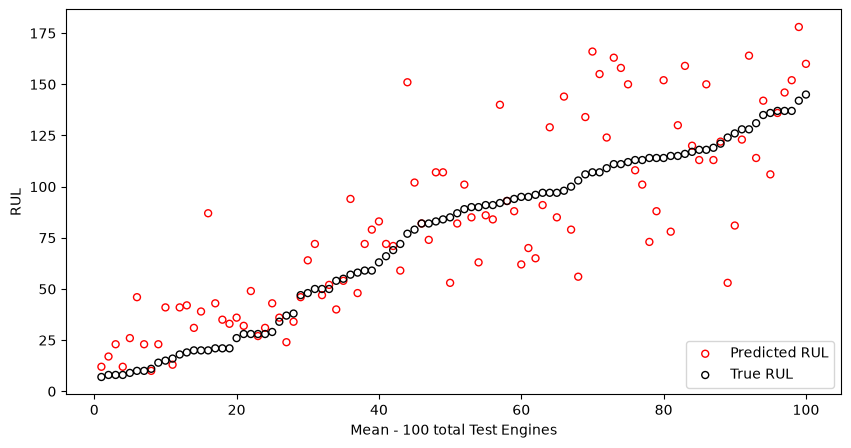

In [24]:
plot1 = plot_rul_comparison(compare_df, pred_col=['RUL_pred_mean'],true_col='RUL', title='Mean')

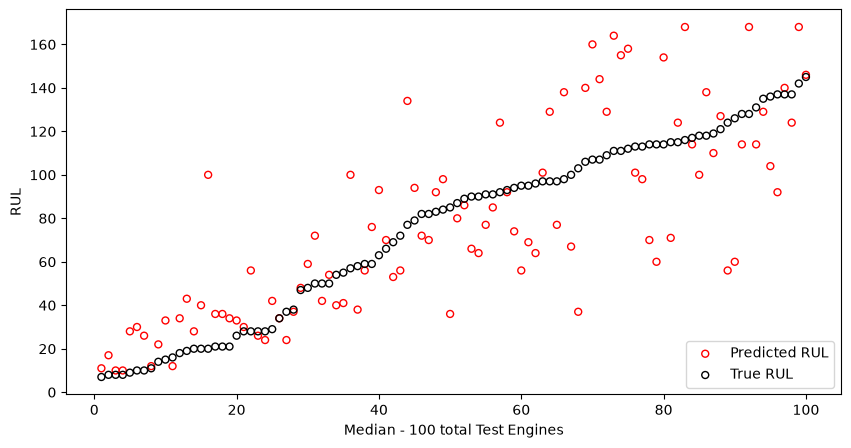

In [25]:
plot1 = plot_rul_comparison(compare_df, pred_col=['RUL_pred_median'],true_col='RUL',title='Median')

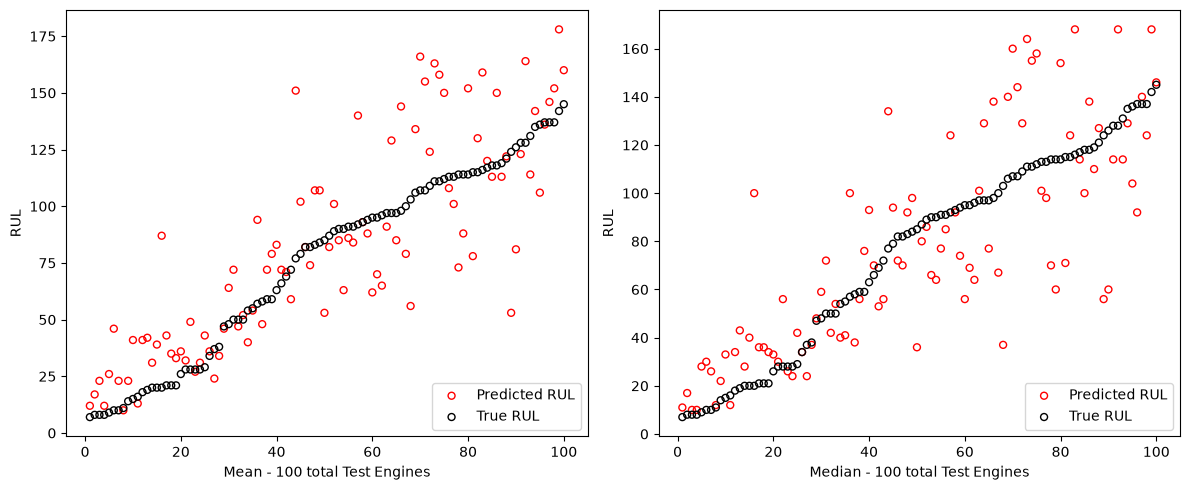

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_rul_comparison(compare_df, "RUL_pred_mean",true_col='RUL', title="Mean", ax=axes[0])
plot_rul_comparison(compare_df, "RUL_pred_median", true_col='RUL', title="Median", ax=axes[1])
plt.tight_layout()
plt.show()